## Potato Leaf Disease Detection using Image Classification

## 🧩 Problem Statement

Potato crops are highly susceptible to diseases such as Early Blight and Late Blight, which can significantly reduce agricultural yield and quality. Traditional methods of disease detection rely on manual inspection by experts, which is time-consuming, error-prone, and not scalable for large farms.

This project aims to develop an automated image classification system using deep learning techniques to accurately identify and classify potato leaf diseases from images. The system will help in early detection, enabling farmers to take timely actions and improve crop productivity.

---

## 🎯 Objectives

- To understand and implement image classification using deep learning techniques  
- To explore and analyze the potato leaf disease dataset  
- To perform data preprocessing, including resizing, normalization, and augmentation  
- To build a Convolutional Neural Network (CNN) model for disease classification  
- To train and validate the model using appropriate datasets  
- To evaluate model performance using metrics such as accuracy, confusion matrix, and classification report  
- To develop a reliable system for detecting Early Blight, Late Blight, and Healthy potato leaves  

## 🔄 Project Pipeline: Potato Leaf Disease Detection using CNN

### 1️⃣ Dataset Acquisition
- Imported required libraries: TensorFlow, NumPy, Matplotlib, etc.
- Downloaded dataset using KaggleHub:
  - Dataset: Potato Plant Diseases Dataset
- Extracted and set the dataset path for further processing

---

### 2️⃣ Data Loading & Exploration
- Loaded dataset using:
  - `tf.keras.preprocessing.image_dataset_from_directory()`
- Configured:
  - Image size (resizing)
  - Batch size
  - Shuffle enabled
- Automatically detected class labels:
  - Early Blight
  - Late Blight
  - Healthy
- Visualized sample images from each class using Matplotlib

---

### 3️⃣ Dataset Splitting
- Created a custom function to split dataset into:
  - Training set (80%)
  - Validation set (10%)
  - Test set (10%)
- Used TensorFlow dataset operations:
  - `.take()`
  - `.skip()`

---

### 4️⃣ Data Preprocessing & Augmentation
- Applied preprocessing techniques:
  - Rescaling pixel values (normalization)
- Implemented data augmentation:
  - Random flipping
  - Random rotation
  - (Possibly other transformations)
- Integrated preprocessing directly into the model pipeline

---

### 5️⃣ Model Building (CNN Architecture)
- Built a Sequential CNN model with:
  - Input layer
  - Data augmentation layer
  - Rescaling layer
  - Convolutional layers (feature extraction)
  - Pooling layers (dimensionality reduction)
  - Flatten layer
  - Dense (fully connected) layers
  - Output layer with softmax activation
- Defined:
  - Loss function: Categorical Crossentropy
  - Optimizer: Adam
  - Metrics: Accuracy

---

### 6️⃣ Model Training
- Trained model using:
  - Training dataset
  - Validation dataset
- Parameters:
  - Epochs
  - Batch size
- Stored training history:
  - Accuracy
  - Validation Accuracy
  - Loss
  - Validation Loss

---

### 7️⃣ Model Performance Visualization
- Plotted:
  - Training vs Validation Accuracy
  - Training vs Validation Loss
- Used Matplotlib for visualization
- Analyzed overfitting/underfitting behavior

---

### 8️⃣ Model Evaluation on Test Data
- Evaluated final model on unseen test dataset:
  - Computed test accuracy and loss
- Generated predictions on test data

---

### 9️⃣ Confusion Matrix & Classification Report
- Computed confusion matrix using `sklearn.metrics`
- Normalized confusion matrix for better interpretability
- Visualized using Seaborn heatmap
- Generated classification report including:
  - Precision
  - Recall
  - F1-score

---

### 🔟 Model Saving
- Saved trained model in Keras format:
  - `potato_disease_model.keras`
- Enables future inference and deployment

---

### 1️⃣1️⃣ Advanced Evaluation Metrics
- Computed additional performance metrics:
  - ROC Curve (Receiver Operating Characteristic)
  - AUC Score
  - Precision-Recall Curve
- Used:
  - `label_binarize` for multiclass handling
  - `roc_curve`, `auc`, `precision_recall_curve`

---

### 1️⃣2️⃣ Final Results Summary
- Created a summary table including:
  - Total test samples
  - Final test accuracy
  - Final test loss
  - Number of classes
- Displayed results using Pandas DataFrame

---

## ✅ Final Outcome
- Successfully built a CNN-based image classification model
- Achieved accurate classification of potato leaf diseases
- Model capable of detecting:
  - Early Blight
  - Late Blight
  - Healthy leaves
- Ready for deployment in real-world agricultural applications

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers, Input
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Download Dataset
path = kagglehub.dataset_download("hafiznouman786/potato-plant-diseases-data")

# 2. Set the exact path discovered during exploration
dataset_path = os.path.join(path, 'PlantVillage/PlantVillage')

# 3. Define Constants
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 15 # Adjusted for a standard 15-min demo

print("Dataset ready at:", dataset_path)

Using Colab cache for faster access to the 'potato-plant-diseases-data' dataset.
Dataset ready at: /kaggle/input/potato-plant-diseases-data/PlantVillage/PlantVillage


Found 2152 files belonging to 3 classes.
Detected Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


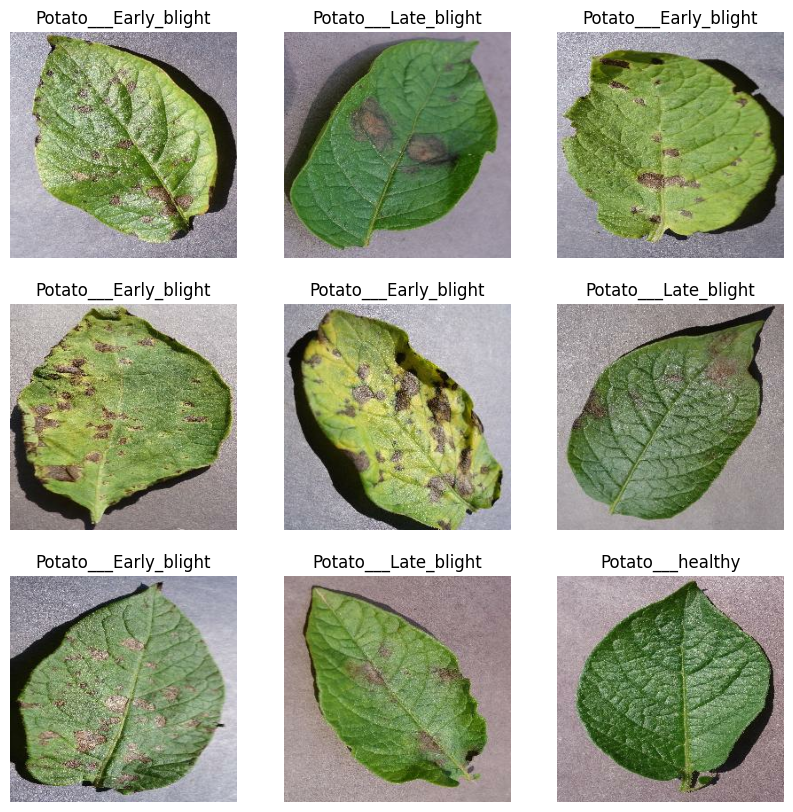

In [2]:
# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Detected Classes:", class_names)

# Visualize samples
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [3]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1):
    ds_size = len(ds)
    train_ds = ds.take(int(train_split * ds_size))
    val_ds = ds.skip(int(train_split * ds_size)).take(int(val_split * ds_size))
    test_ds = ds.skip(int(train_split * ds_size)).skip(int(val_split * ds_size))
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

# Augmentation layer to make the model robust
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Optimize performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [5]:
# Model Building (CNN Architecture)
# We define the CNN layers specifically designed for leaf pattern recognition.
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    Input(shape=input_shape),
    data_augmentation,
    layers.Rescaling(1./255), # Normalization

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# model training
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.7257 - loss: 0.7029 - val_accuracy: 0.8750 - val_loss: 0.3817
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.8819 - loss: 0.3100 - val_accuracy: 0.9583 - val_loss: 0.1661
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9323 - loss: 0.1729 - val_accuracy: 0.9271 - val_loss: 0.2230
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9265 - loss: 0.1925 - val_accuracy: 0.9583 - val_loss: 0.1504
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9340 - loss: 0.1665 - val_accuracy: 0.8125 - val_loss: 0.5617
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9456 - loss: 0.1350 - val_accuracy: 0.9323 - val_loss: 0.2345
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9473 - loss: 0.1320 - val_accuracy: 0.8958 - val_loss: 0.2373
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9369 - loss: 0.1574 - val_accuracy: 0.9271 -

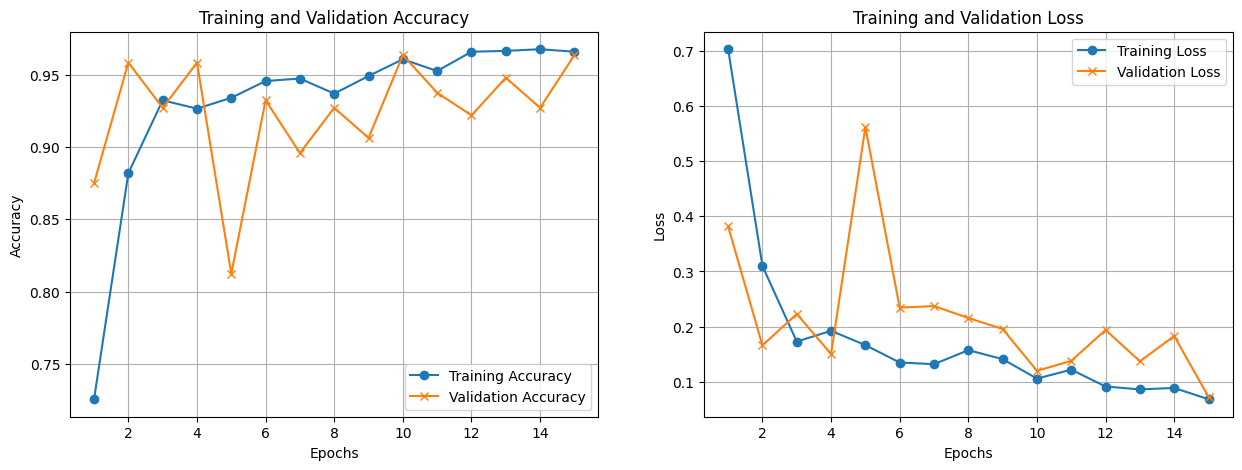

In [9]:
# model evaluation
# Extracting values from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

# Plotting Accuracy and Loss
plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Run evaluation on the unseen Test Dataset
print("Running Final Evaluation on Test Set...")
test_scores = model.evaluate(test_ds, verbose=0)
print(f"Test Loss: {test_scores[0]:.4f}")
print(f"Test Accuracy: {test_scores[1]*100:.2f}%")

# 2. Collect predictions
y_actual = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_actual.extend(labels.numpy())
    y_pred.extend([np.argmax(p) for p in predictions])

# 3. Display Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_actual, y_pred, target_names=class_names))


Running Final Evaluation on Test Set...
Test Loss: 0.0463
Test Accuracy: 97.84%

--- Classification Report ---
                       precision    recall  f1-score   support

Potato___Early_blight       0.97      0.99      0.98       104
 Potato___Late_blight       0.99      0.96      0.98       110
     Potato___healthy       0.95      1.00      0.97        18

             accuracy                           0.98       232
            macro avg       0.97      0.98      0.98       232
         weighted avg       0.98      0.98      0.98       232



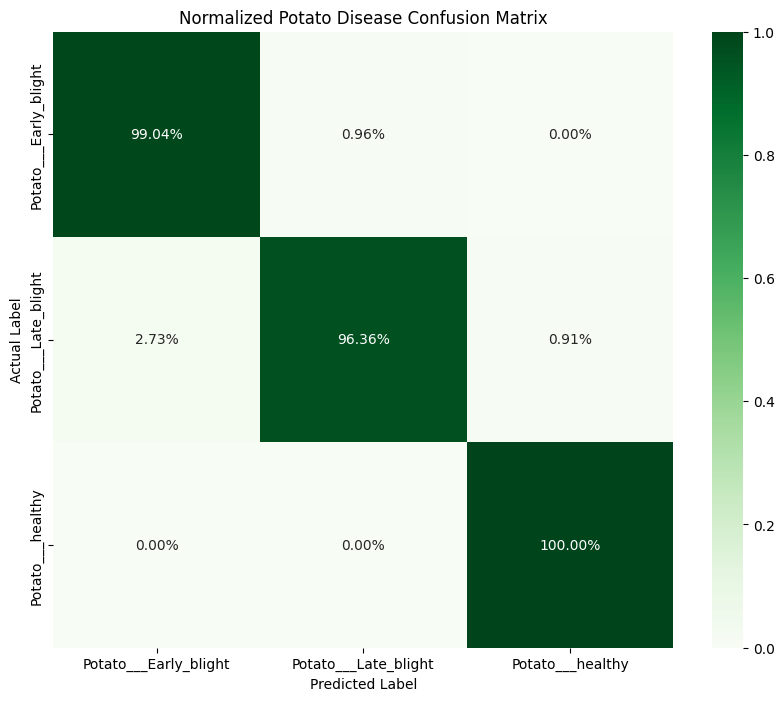

In [11]:
# Updated Confusion Matrix Code (Normalized)
cm = confusion_matrix(y_actual, y_pred)

# Normalize the matrix by row (actual classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Normalized Potato Disease Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [15]:
# Save the model in the recommended native Keras format
model_name = "potato_disease_model.keras"
model.save(model_name)
print(f"Model saved successfully as {model_name}")

Model saved successfully as potato_disease_model.keras


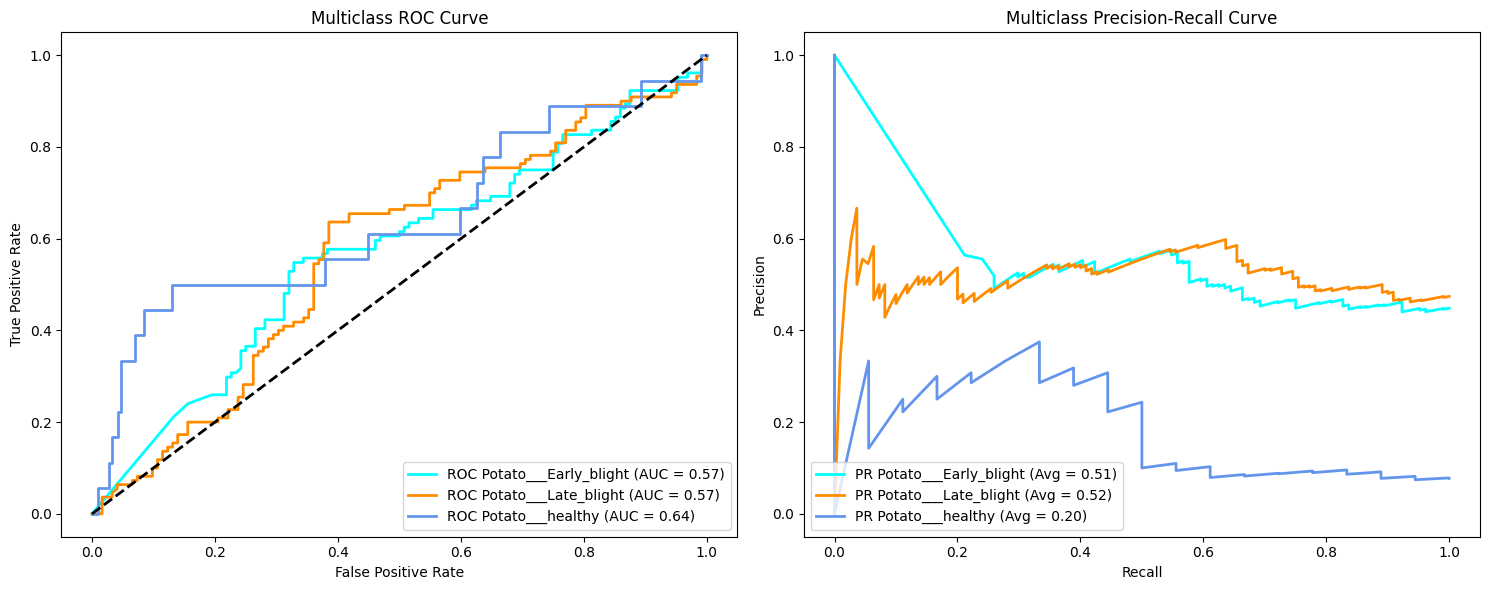

In [16]:
# Advanced Performance Visualization (ROC & PR Curves)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Prepare data for multiclass plotting
y_test_bin = label_binarize(y_actual, classes=[0, 1, 2])
y_score = []

# Get probability scores for each class
for images, _ in test_ds:
    y_score.extend(model.predict(images, verbose=0))
y_score = np.array(y_score)

# 2. Setup Plotting
plt.figure(figsize=(15, 6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

# --- Subplot 1: ROC Curve ---
plt.subplot(1, 2, 1)
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multiclass ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# --- Subplot 2: Precision-Recall Curve ---
plt.subplot(1, 2, 2)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, color=color, lw=2,
             label=f'PR {class_names[i]} (Avg = {avg_precision:0.2f})')

plt.title('Multiclass Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# Calculate final test metrics
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

summary_data = {
    "Metric": ["Total Images Tested", "Final Test Accuracy", "Final Test Loss", "Classes Detected"],
    "Value": [len(y_actual), f"{test_acc*100:.2f}%", f"{test_loss:.4f}", ", ".join(class_names)]
}

summary_df = pd.DataFrame(summary_data)
print("\n--- FINAL PROJECT SUMMARY ---")
display(summary_df)


--- FINAL PROJECT SUMMARY ---


,Metric,Value
0,Total Images Tested,232
1,Final Test Accuracy,97.84%
2,Final Test Loss,0.0463
3,Classes Detected,"Potato___Early_blight, Potato___Late_blight, P..."


In [19]:
# Final Project Insights & Model Summary
import pandas as pd
import numpy as np

print("="*60)
print("📘 PROJECT SUMMARY: Potato Leaf Disease Detection")
print("="*60)

# Basic Info
num_classes = len(class_names)
print(f"\n📌 Number of Classes: {num_classes}")
print(f"📌 Classes: {class_names}")

# Dataset Info
train_count = train_ds.cardinality().numpy()
val_count = val_ds.cardinality().numpy()
test_count = test_ds.cardinality().numpy()

print("\n📂 Dataset Split (in batches):")
print(f"   ➤ Training Batches: {train_count}")
print(f"   ➤ Validation Batches: {val_count}")
print(f"   ➤ Test Batches: {test_count}")

# Model Summary
print("\n🧠 MODEL ARCHITECTURE:")
model.summary()

# Final Metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("\n📈 FINAL TRAINING METRICS:")
print(f"   ➤ Training Accuracy: {final_train_acc:.4f}")
print(f"   ➤ Validation Accuracy: {final_val_acc:.4f}")
print(f"   ➤ Training Loss: {final_train_loss:.4f}")
print(f"   ➤ Validation Loss: {final_val_loss:.4f}")

# Test Evaluation
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print("\n🧪 TEST PERFORMANCE:")
print(f"   ➤ Test Accuracy: {test_acc:.4f}")
print(f"   ➤ Test Loss: {test_loss:.4f}")

# Overfitting Check
print("\n🔍 MODEL INSIGHT:")
if final_val_acc < final_train_acc:
    print("   ➤ Slight overfitting detected (train > validation accuracy)")
elif final_val_acc > final_train_acc:
    print("   ➤ Model generalizes well (validation >= training accuracy)")
else:
    print("   ➤ Balanced model performance")

# Create Summary Table
summary = pd.DataFrame({
    "Metric": ["Train Accuracy", "Validation Accuracy", "Test Accuracy",
               "Train Loss", "Validation Loss", "Test Loss"],
    "Value": [final_train_acc, final_val_acc, test_acc,
              final_train_loss, final_val_loss, test_loss]
})

print("\n📋 FINAL SUMMARY TABLE:")
print(summary)

print("\n✅ Project completed successfully!")
print("="*60)

📘 PROJECT SUMMARY: Potato Leaf Disease Detection

📌 Number of Classes: 3
📌 Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

📂 Dataset Split (in batches):
   ➤ Training Batches: 54
   ➤ Validation Batches: 6
   ➤ Test Batches: 8

🧠 MODEL ARCHITECTURE:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,228,939 (42.84 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,485,960 (28.56 MB)


📈 FINAL TRAINING METRICS:
   ➤ Training Accuracy: 0.9659
   ➤ Validation Accuracy: 0.9635
   ➤ Training Loss: 0.0684
   ➤ Validation Loss: 0.0727

🧪 TEST PERFORMANCE:
   ➤ Test Accuracy: 0.9784
   ➤ Test Loss: 0.0463

🔍 MODEL INSIGHT:
   ➤ Slight overfitting detected (train > validation accuracy)

📋 FINAL SUMMARY TABLE:
                Metric     Value
0       Train Accuracy  0.965856
1  Validation Accuracy  0.963542
2        Test Accuracy  0.978448
3           Train Loss  0.068449
4      Validation Loss  0.072687
5            Test Loss  0.046331

✅ Project completed successfully!
